In [4]:
conda install numpy pandas matplotlib seaborn scikit-learn scipy jupyter

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [7]:
# ============================================
# Load Synthetic Auto MPG Dataset
# ============================================

try:
    # Attempt to load the local dataset
    df = pd.read_csv("auto_mpg_synthetic_dataset.csv")
    print("Dataset loaded successfully from local file!")

except:
    print("Local file load failed.")
    print("Generating synthetic dataset...")

    np.random.seed(42)
    n_samples = 900

    df = pd.DataFrame(
        {
            "mpg": np.random.uniform(8.0, 46.6, n_samples),
            "cylinders": np.random.choice([3, 4, 5, 6, 8], n_samples),
            "displacement": np.random.uniform(158.1, 500.0, n_samples),
            "horsepower": np.random.randint(79, 240, n_samples),
            "weight": np.random.randint(1500, 4955, n_samples),
            "acceleration": np.random.uniform(9.8, 20.2, n_samples),
            "model_year": np.random.randint(70, 83, n_samples),
            "origin": np.random.choice([1, 2, 3], n_samples),
            "car_name": [f"Car_{i:03d}" for i in range(1, n_samples + 1)],
        }
    )

    # Create a relationship between features and fuel efficiency (mpg)
    df["mpg"] = (
        55
        - (df["weight"] * 0.006)
        - (df["horsepower"] * 0.05)
        + np.random.normal(0, 2.5, n_samples)
    ).astype(float)

    # Limit mpg values to realistic values
    df["mpg"] = df["mpg"].clip(lower=8.0, upper=46.6)

    print("Synthetic dataset created successfully!")

Dataset loaded successfully from local file!


2. Display the first five rows.

In [8]:
print("First Five Rows:")
df.head()

First Five Rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,25.6,4,240.8,144,2832,18.2,72,1,Car_001
1,34.4,8,411.6,140,2344,15.9,79,1,Car_002
2,12.9,6,392.2,210,4301,14.5,76,3,Car_003
3,19.9,5,322.4,170,3244,16.9,76,1,Car_004
4,39.9,4,253.9,79,1500,17.4,70,1,Car_005


3. Display the dataset shape.

In [9]:
print ('dataset shape')
print("-" * 50)
print(f"Dataset Shape: {df.shape}")

dataset shape
--------------------------------------------------
Dataset Shape: (300, 9)


4. Display info()

In [10]:
print("Dataset Information")
print("-" * 50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           300 non-null    float64
 1   cylinders     300 non-null    int64  
 2   displacement  300 non-null    float64
 3   horsepower    300 non-null    int64  
 4   weight        300 non-null    int64  
 5   acceleration  300 non-null    float64
 6   model_year    300 non-null    int64  
 7   origin        300 non-null    int64  
 8   car_name      300 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 21.2+ KB


5. Display describe()

In [11]:
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  300.000000  300.000000    300.000000  300.000000   300.000000   
mean    27.211000    5.196667    316.861333  153.580000  2796.476667   
std      7.564451    1.494020     73.708896   32.989969   678.251591   
min      8.000000    3.000000    158.100000   79.000000  1500.000000   
25%     21.500000    4.000000    258.975000  129.750000  2291.750000   
50%     27.850000    4.000000    295.750000  153.500000  2789.000000   
75%     32.425000    6.000000    362.350000  175.000000  3244.750000   
max     46.600000    8.000000    500.000000  239.000000  4955.000000   

       acceleration  model_year      origin  
count    300.000000    300.0000  300.000000  
mean      15.067667     76.0500    1.836667  
std        2.039490      3.5782    0.867466  
min        9.800000     70.0000    1.000000  
25%       13.600000     73.0000    1.000000  
50%       15.100000     76.0000    2.000000  
75%       16.400000     79.00

Questions
1. How many observations are in the dataset?
   There are 300 unique observations (from Car_001 to Car_300).
2. Which column is the target variable?
   mpg (Miles Per Gallon).
3. Which column contains text?
   car_name

Exercise 2: Missing Values

1. Check for missing values.

In [12]:
print("Missing Values")
print("-" * 50)

print(df.isnull().sum())

Missing Values
--------------------------------------------------
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


2. If any exist, remove them

there is no null value 

3. Display the new dataset shape

In [13]:
print ('new dataset shape')
print("-" * 50)
print(f"Dataset Shape: {df.shape}")

new dataset shape
--------------------------------------------------
Dataset Shape: (300, 9)


1. Which columns contain missing values?
   there is no column that contains missing value
2. Why should missing values be handled before training?
   Linear Regression uses matrix algebra to compute parameters. Algorithms in packages like scikit-learn
   cannot handle null values mathematically and will throw an execution error if they are not cleaned first.
   

Exercise 3: Exploratory Data Analysis
Create:
Histogram of MPG
Box plot of MPG
Correlation matrix
Correlation bar chart
Scatter plots:
MPG vs Weight
MPG vs Horsepower
MPG vs Cylinders
MPG vs Displacement
MPG vs Acceleration
MPG vs Model Year

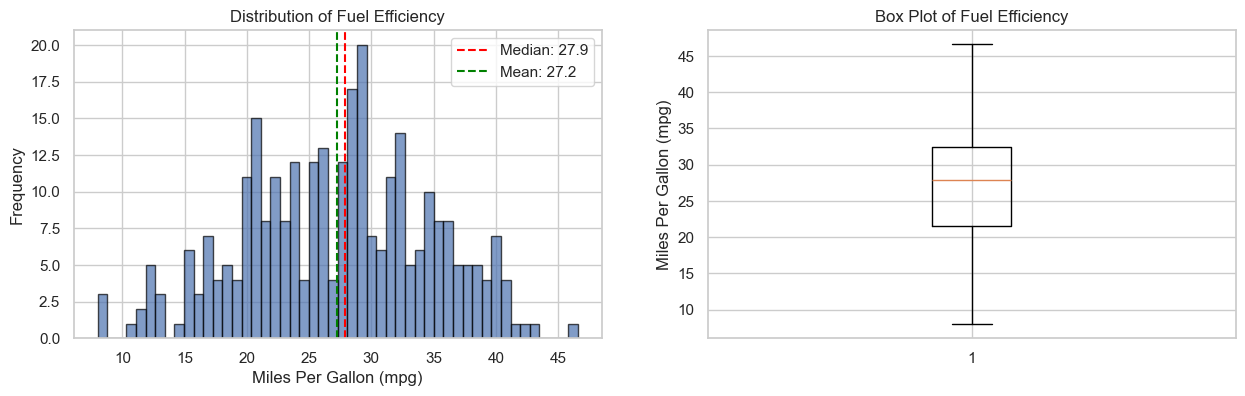

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
# Histogram

axes[0].hist(
    df["mpg"],
    bins=50,
    edgecolor="black",
    alpha=0.7
)

axes[0].set_title("Distribution of Fuel Efficiency")
axes[0].set_xlabel("Miles Per Gallon (mpg)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    df["mpg"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['mpg'].median():.1f}"
)

axes[0].axvline(
    df["mpg"].mean(),
    color="green",
    linestyle="--",
    label=f"Mean: {df['mpg'].mean():.1f}"
)
axes[0].legend()
# Box Plot

axes[1].boxplot(df["mpg"])
axes[1].set_title("Box Plot of Fuel Efficiency")
axes[1].set_ylabel("Miles Per Gallon (mpg)")
plt.show()

In [16]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
    df[numeric_columns]
    .corr()["mpg"]
    .sort_values(ascending=False)
)

print("Top Correlations with Fuel Efficiency (mpg)")
print(correlations)

Top Correlations with Fuel Efficiency (mpg)
mpg             1.000000
origin          0.116329
model_year      0.101659
acceleration    0.043016
cylinders      -0.069677
displacement   -0.290129
horsepower     -0.824688
weight         -0.927553
Name: mpg, dtype: float64


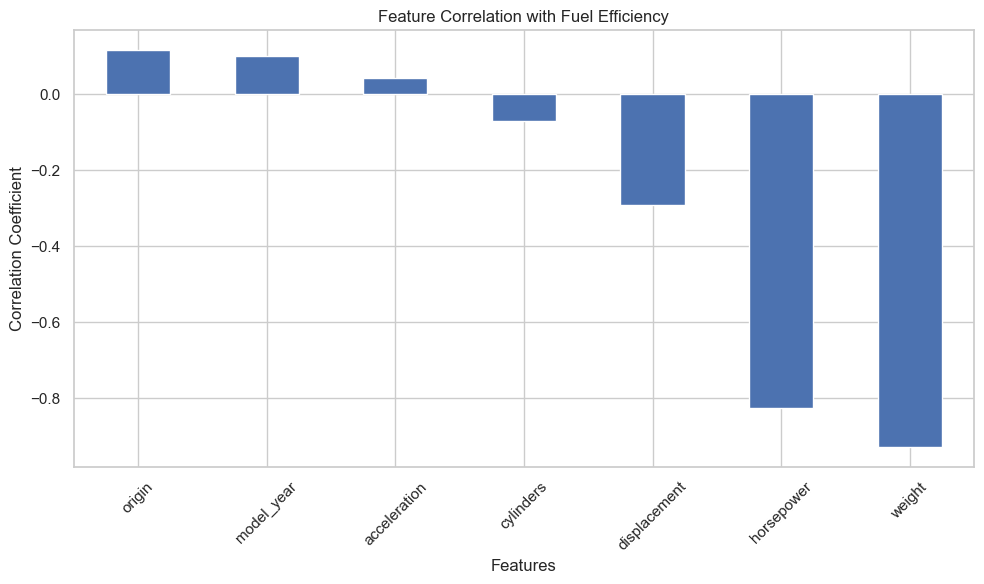

In [21]:
plt.figure(figsize=(10, 6))
correlations.drop("mpg").plot(kind="bar")
plt.title("Feature Correlation with Fuel Efficiency")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

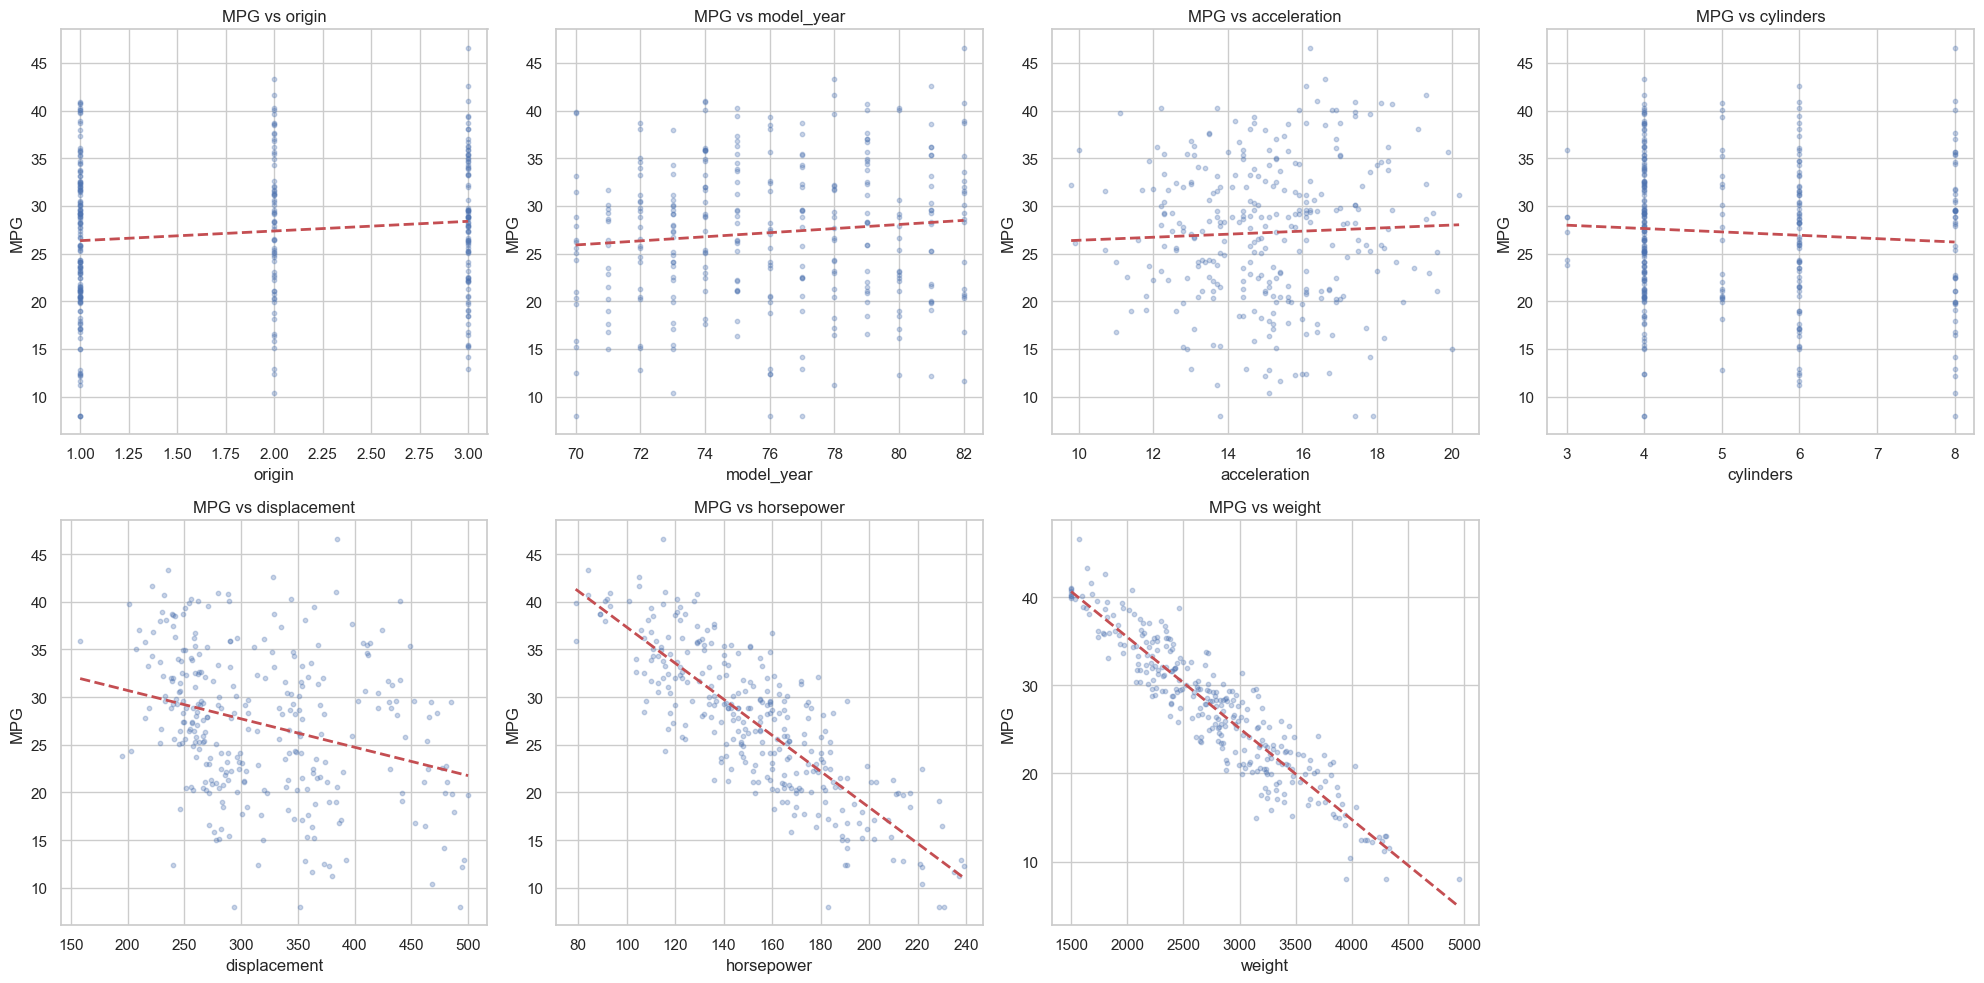

In [27]:

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
features = [
    "origin",
    "model_year",
    "acceleration",
    "cylinders",
    "displacement",
    "horsepower",
    "weight"
]

for index, feature in enumerate(features):
    row = index // 4
    column = index % 4

    # Scatter plot data points
    axes[row, column].scatter(
        df[feature],
        df["mpg"],
        alpha=0.3,
        s=10
    )

    axes[row, column].set_title(f"MPG vs {feature}")
    axes[row, column].set_xlabel(feature)
    axes[row, column].set_ylabel("MPG")

    z = np.polyfit(df[feature], df["mpg"], 1)
    p = np.poly1d(z)
    
    axes[row, column].plot(
        df[feature].sort_values(),
        p(df[feature].sort_values()),
        "r--",
        linewidth=2
    )
if len(features) < 8:
    axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

1. MPG vs Origin
   Direction: Positive
   Strength: Weak / Negligible (Correlation: +0.12)
   Outliers: None; data aligns in strict vertical strips due to its categorical nature (1,2,3). Cars from origin categories 2 and 3 show slightly                   higher baseline efficiency metrics than category 1.
2. MPG vs Model Year
   Direction: Positive
   Strength: Weak (Correlation: +0.11)
   Outliers: None; points align vertically inside discrete years, tracing out a very subtle upward movement over time.
3. MPG vs Acceleration
   Direction: Positive
   Strength: Virtually Non-existent (Correlation: +0.05)
   Outliers: None; points resemble a standard uniform cloud distribution with no definitive direction.
4. MPG vs Cylinders
   Direction: Negative
   Strength: Extremely Weak (Correlation: −0.08)
   Outliers: Yes; a small scattering of 3-cylinder and 8-cylinder cars run completely against their cluster expectations to get abnormally high fuel                efficiency.
5. MPG vs Displacement
   Direction: Negative
   Strength: Weak / Moderate (Correlation: −0.30)
   Outliers: Highly dispersed data; significant vertical scattering is visible around the 250–380 displacement range.
6. MPG vs Horsepower
   Direction: Negative
   Strength: Strong (Correlation: −0.83)
   Outliers: None; forms a clean down-trending channel.
7. MPG vs Weight
   Direction: Negative
   Strength: Extremely Strong (Correlation: −0.93)
   Outliers: Virtually none; data points lock tightly into a sharp downward-sloping linear line.